# 05 — Sensitivity to kNN parameter k

**Purpose:** Test sensitivity to k (number of neighbors in the kNN graph). Vary k ∈ {10, 20, 30, 50}, compute spatial metrics, plot stabilization curves.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import display_dataset_name, RAW_RESULTS, thesis_figure_dir, apply_thesis_plot_style

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
apply_thesis_plot_style()
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", message=".*not fully connected.*", category=UserWarning)

from analysis.preprocessing import get_transformed_test_features

RESULTS_DIR = RAW_RESULTS
FIG_DIR = thesis_figure_dir("nb05")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from analysis.cache import load_or_compute_df


## Loop over k and store results

In [2]:
from analysis.sensitivity import compute_knn_sensitivity, compute_knn_hh_overlay

K = 25
K_NN_LIST = [10, 20, 30, 50, 60, 70, 80, 90, 100]

SUPPORTED_DATASETS = ("compas", "german", "adult")

df_knn = load_or_compute_df(
    CACHE_DIR / f"nb05_knn_sensitivity_{CACHE_VERSION}.parquet",
    lambda: compute_knn_sensitivity(
        RESULTS_DIR,
        datasets=SUPPORTED_DATASETS,
        k_values=K_NN_LIST,
        K=K,
    ),
    force=FORCE_RECOMPUTE,
)

df_hh_overlay = load_or_compute_df(
    CACHE_DIR / f"nb05_knn_hh_overlay_{CACHE_VERSION}.parquet",
    lambda: compute_knn_hh_overlay(
        RESULTS_DIR,
        datasets=SUPPORTED_DATASETS,
        k_values=K_NN_LIST,
        K=K,
    ),
    force=FORCE_RECOMPUTE,
)


## Stabilization curves

Mean ± std bands over seeds for variance-based and conflict-based metrics

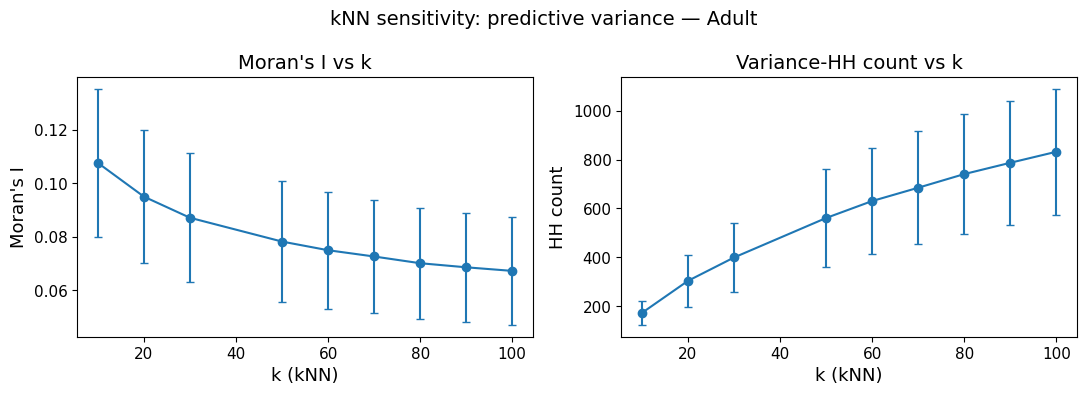

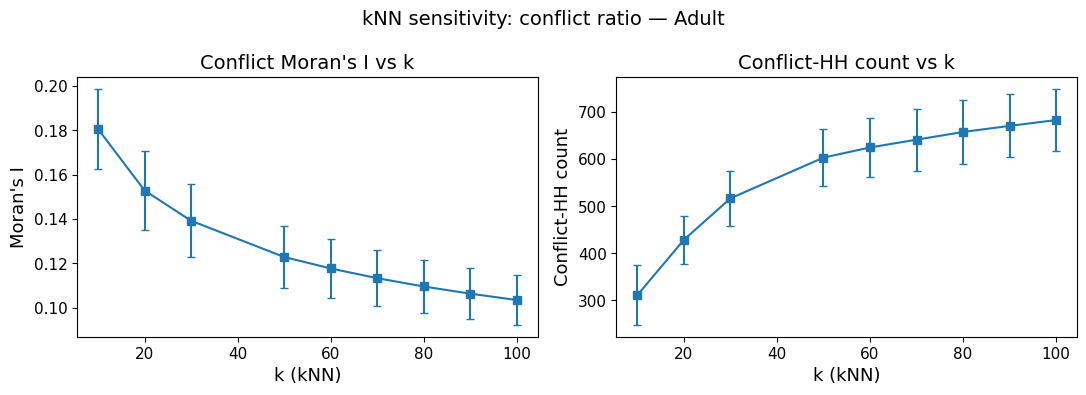

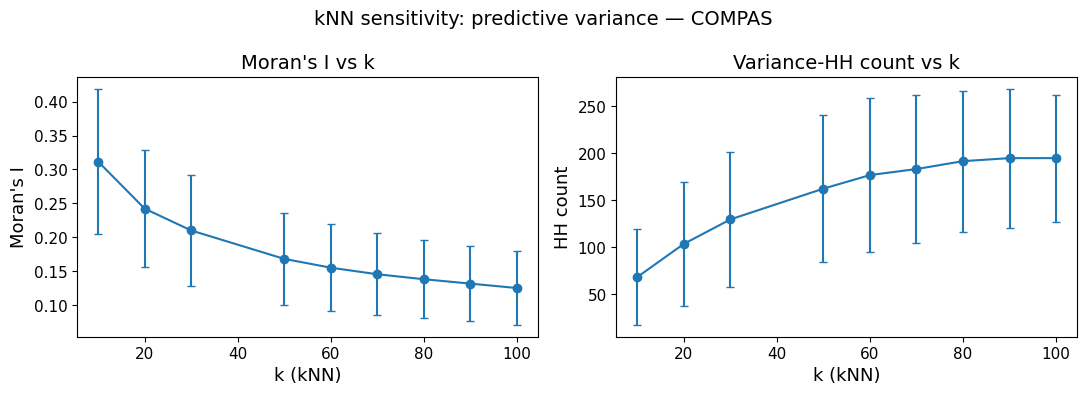

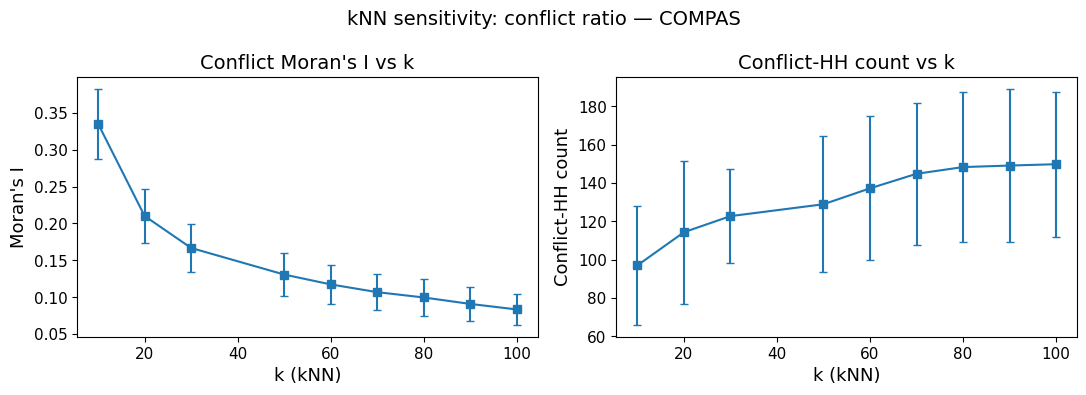

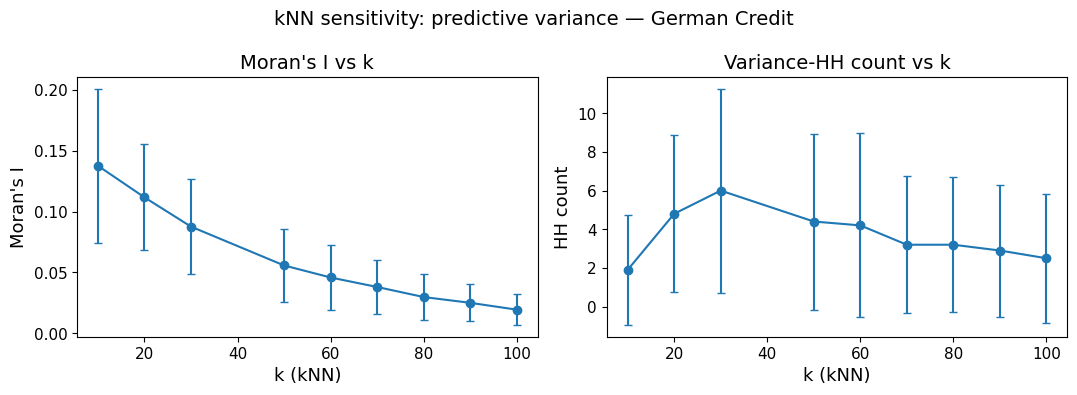

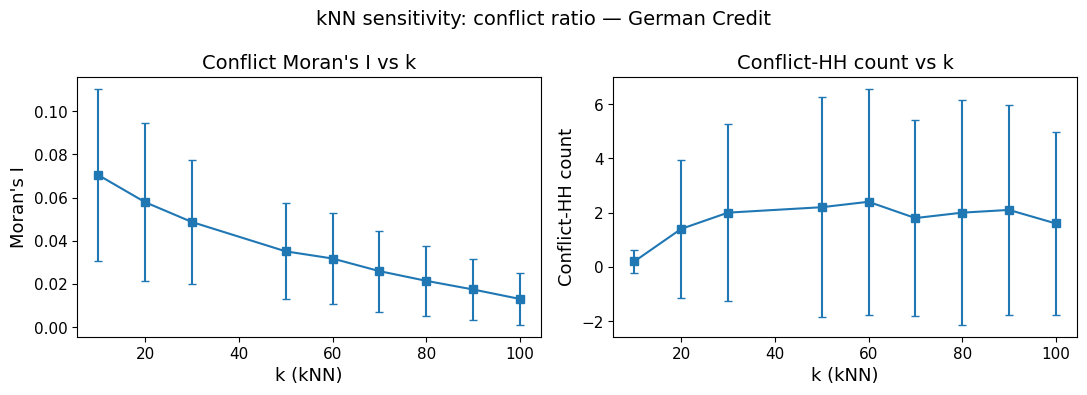

In [3]:
agg_knn = df_knn.groupby(["dataset", "k_nn"]).agg(
    mean_variance_mean=("mean_variance", "mean"),
    mean_variance_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"),
    n_hh_std=("n_hh", "std"),
    conflict_moran_mean=("conflict_moran_i", "mean"),
    conflict_moran_std=("conflict_moran_i", "std"),
    conflict_n_hh_mean=("conflict_n_hh", "mean"),
    conflict_n_hh_std=("conflict_n_hh", "std"),
).reset_index()

for ds_name, ds_agg in agg_knn.groupby("dataset"):
    d = ds_agg.sort_values("k_nn")

    # ------------------------------------------------------------------
    # Predictive-variance kNN sensitivity
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].errorbar(
        d["k_nn"], d["moran_mean"],
        yerr=d["moran_std"],
        marker="o", capsize=3
    )
    axes[0].set_xlabel("k (kNN)")
    axes[0].set_ylabel("Moran's I")
    axes[0].set_title("Moran's I vs k")

    axes[1].errorbar(
        d["k_nn"], d["n_hh_mean"],
        yerr=d["n_hh_std"],
        marker="o", capsize=3
    )
    axes[1].set_xlabel("k (kNN)")
    axes[1].set_ylabel("HH count")
    axes[1].set_title("Variance-HH count vs k")

    fig.suptitle(f"kNN sensitivity: predictive variance — {display_dataset_name(ds_name)}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_variance_{ds_name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------------
    # Conflict-ratio kNN sensitivity
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].errorbar(
        d["k_nn"], d["conflict_moran_mean"],
        yerr=d["conflict_moran_std"],
        marker="s", capsize=3
    )
    axes[0].set_xlabel("k (kNN)")
    axes[0].set_ylabel("Moran's I")
    axes[0].set_title("Conflict Moran's I vs k")

    axes[1].errorbar(
        d["k_nn"], d["conflict_n_hh_mean"],
        yerr=d["conflict_n_hh_std"],
        marker="s", capsize=3
    )
    axes[1].set_xlabel("k (kNN)")
    axes[1].set_ylabel("Conflict-HH count")
    axes[1].set_title("Conflict-HH count vs k")

    fig.suptitle(f"kNN sensitivity: conflict ratio — {display_dataset_name(ds_name)}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_conflict_{ds_name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Graph connectivity diagnostic

Number of connected components and largest component fraction as a function of k_nn. Small k can lead to disconnected graphs.

In [4]:
conn_agg = df_knn.groupby(["dataset", "k_nn"]).agg(
    comp_mean=("n_components", "mean"), comp_std=("n_components", "std"),
    comp_max=("n_components", "max"),
    frac_mean=("largest_component_frac", "mean"), frac_std=("largest_component_frac", "std"),
    frac_min=("largest_component_frac", "min"),
).reset_index()

**Dataset-specific default k.** For each dataset, the default neighborhood size used in downstream spatial analyses is the **smallest candidate k** in this notebook’s grid such that the **symmetrized** kNN graph is **fully connected in every outer run** on the transformed test features (`comp_max == 1` and `frac_min ≈ 1.0` in the aggregated connectivity table above). Values in `analysis.knn_defaults.K_NN_BY_DATASET` should match the table printed in the next cell (or be set slightly above the minimum when a comment there justifies stability, e.g. COMPAS at k=30).

In [5]:
from IPython.display import display

CRITERION = "smallest k with comp_max=1 and frac_min=1.0"

rows = []
for ds, g in conn_agg.groupby("dataset", sort=False):
    g = g.sort_values("k_nn", ascending=True)
    ok = g[(g["comp_max"] == 1) & (np.isclose(g["frac_min"], 1.0))]
    if ok.empty:
        rows.append({"dataset": ds, "chosen_k": None, "criterion": CRITERION})
        print(f"WARNING: {ds}: no k in grid satisfies {CRITERION}")
    else:
        k_star = int(ok.iloc[0]["k_nn"])
        rows.append({"dataset": ds, "chosen_k": k_star, "criterion": CRITERION})
        print(f"{ds}: chosen k = {k_star} (smallest fully connected across all runs)")

chosen_k_df = pd.DataFrame(rows)
display(chosen_k_df)

adult: chosen k = 60 (smallest fully connected across all runs)
compas: chosen k = 20 (smallest fully connected across all runs)
german: chosen k = 10 (smallest fully connected across all runs)


,dataset,chosen_k,criterion
0,adult,60,smallest k with comp_max=1 and frac_min=1.0
1,compas,20,smallest k with comp_max=1 and frac_min=1.0
2,german,10,smallest k with comp_max=1 and frac_min=1.0


## HH regions in feature space across k_nn

PCA scatter of X_test for a representative run (median Moran's I) at each k_nn value, with variance-HH highlighted.

compas: representative seed = seed=2 (median Moran's I = 0.1796)


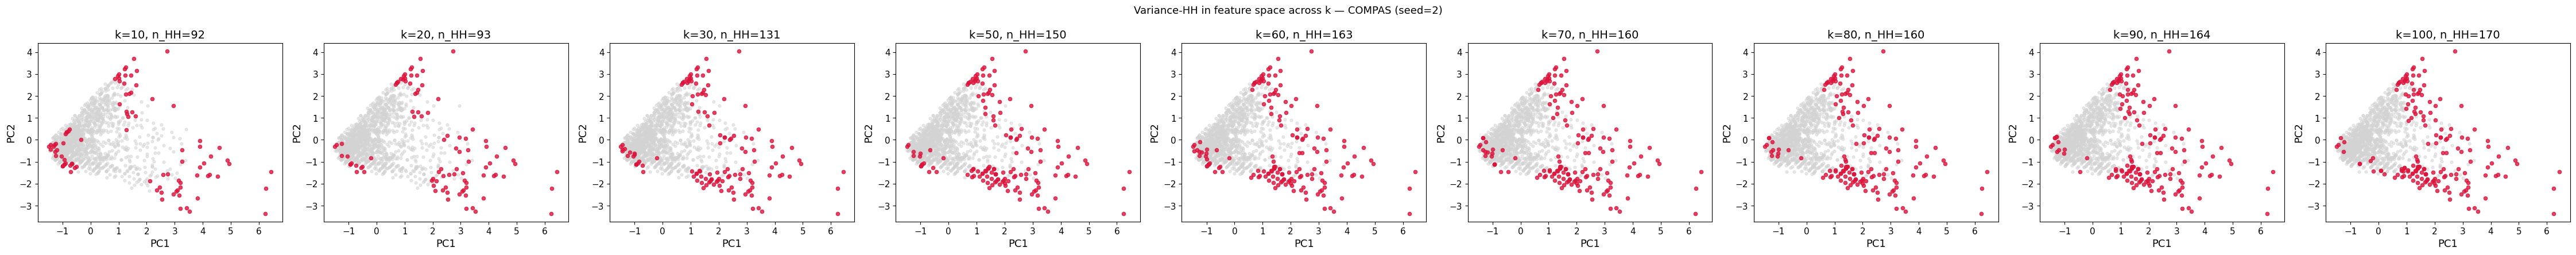

german: representative seed = seed=0 (median Moran's I = 0.0575)


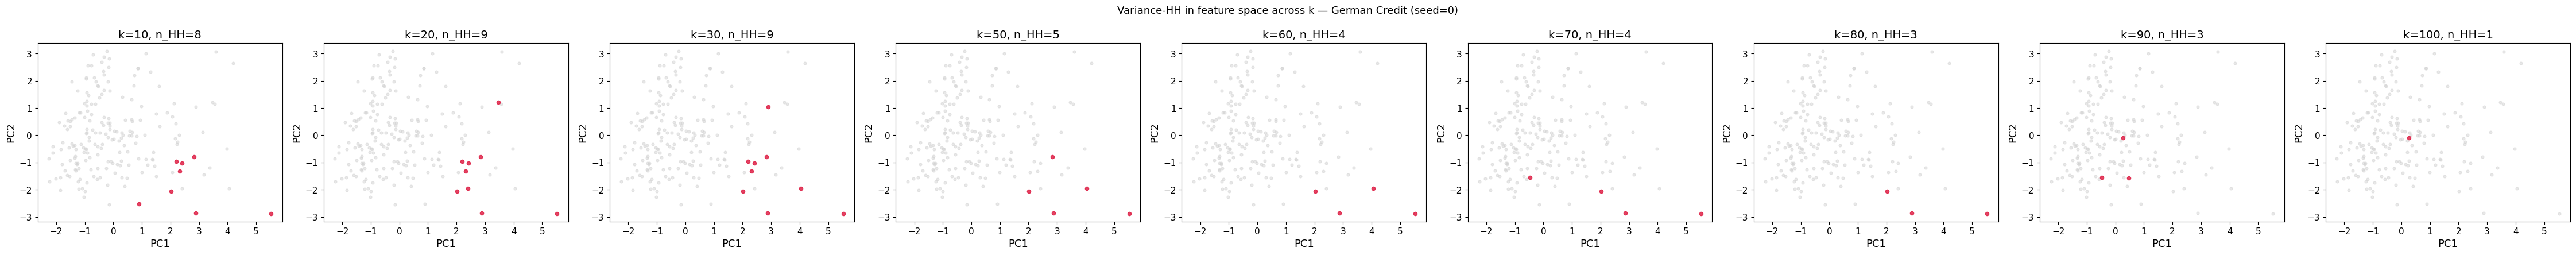

adult: representative seed = seed=5 (median Moran's I = 0.0774)


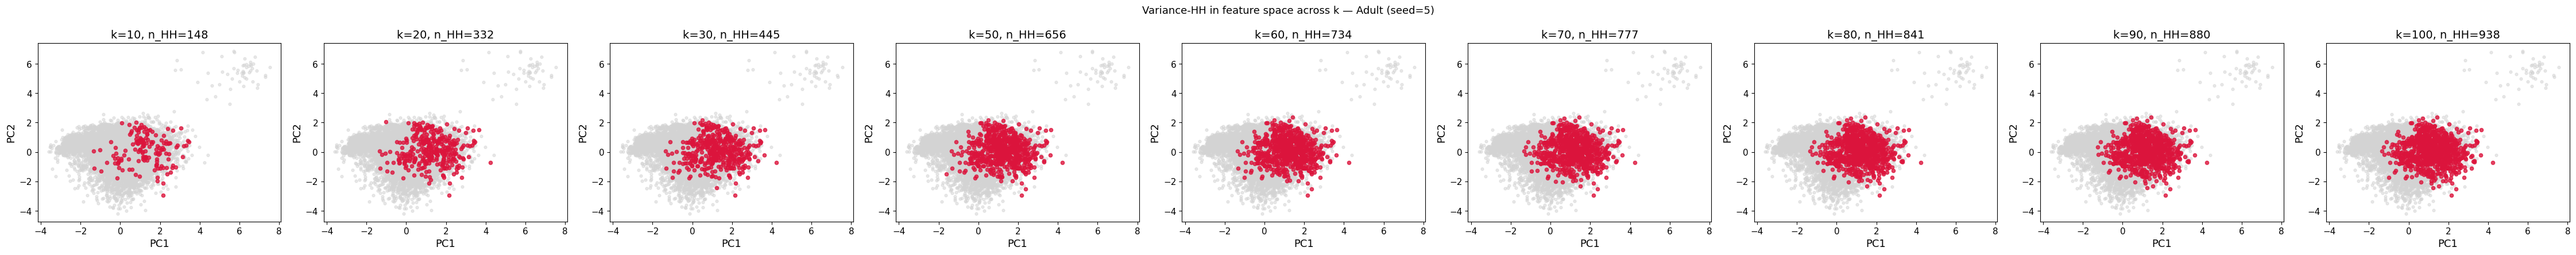

In [6]:
# Rebuild hh_data_by_knn from cached overlay (X_test loaded per run for plotting only)
hh_data_by_knn = {}
for (dataset_name, seed_name, k_nn_val), grp in df_hh_overlay.groupby(["dataset", "seed", "k_nn"]):
    run_dir = RESULTS_DIR / dataset_name / seed_name
    X_test = get_transformed_test_features(run_dir, dataset_name)
    hh_mask = grp.sort_values("point_idx")["is_hh"].to_numpy(dtype=bool)
    hh_data_by_knn[(dataset_name, seed_name, k_nn_val)] = {"HH_mask": hh_mask, "X_test": X_test}

for ds_name in df_knn["dataset"].unique():
    ds_sub = df_knn[(df_knn["dataset"] == ds_name)]
    seeds = ds_sub["seed"].unique()

    moran_per_seed = ds_sub.groupby("seed")["moran_i"].mean()
    median_moran = moran_per_seed.median()
    rep_seed = moran_per_seed.index[np.argmin(np.abs(moran_per_seed.values - median_moran))]
    print(f"{ds_name}: representative seed = {rep_seed} (median Moran's I = {median_moran:.4f})")

    k_list = sorted(ds_sub["k_nn"].unique())
    n_k = len(k_list)
    fig, axes = plt.subplots(1, n_k, figsize=(5 * n_k, 4.5))
    if n_k == 1:
        axes = [axes]

    for ax, k_val in zip(axes, k_list):
        key = (ds_name, rep_seed, k_val)
        if key not in hh_data_by_knn:
            ax.set_title(f"k={k_val} (no data)")
            continue
        data = hh_data_by_knn[key]
        X_test = data["X_test"]
        hh = data["HH_mask"]
        n_features = X_test.shape[1]
        if n_features > 2:
            pca = PCA(n_components=2, random_state=42, svd_solver="full")
            coords = pca.fit_transform(X_test)
        else:
            coords = np.asarray(X_test)

        ax.scatter(coords[~hh, 0], coords[~hh, 1], c="lightgray", s=12, alpha=0.5)
        ax.scatter(coords[hh, 0], coords[hh, 1], c="crimson", s=20, alpha=0.8)
        ax.set_title(f"k={k_val}, n_HH={int(hh.sum())}")
        ax.set_xlabel("PC1" if n_features > 2 else "Feature 1")
        ax.set_ylabel("PC2" if n_features > 2 else "Feature 2")

    fig.suptitle(f"Variance-HH in feature space across k — {display_dataset_name(ds_name)} ({rep_seed})", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_pca_hh_{ds_name}.pdf", bbox_inches="tight")
    plt.show()